# Laboratorio Semana 9

*   Juan Huertas
*   Martin Novoa
*   Daniel Peñaloza



## 1) Descripción del problema





## 2) Requerimientos


## **Requerimientos Funcionales**

- RF1 **Representación del Grafo:** El sistema debe implementar y almacenar la red de bodegas utilizando una estructura de lista de adyacencia

- RF2 **Carga de Datos Iniciales:** El sistema debe permitir registrar un conjunto inicial predefinido de vértices (A, B, C, D, E, F, G, H) y sus respectivas aristas.

- RF3 **Visualización de Estructuras:** El programa debe mostrar en pantalla la estructura del grafo una vez cargados los datos. Específicamente, debe imprimir la lista de adyacencia y la matriz de adyacencia.

- RF4 **Búsqueda por Anchura (BFS):** El sistema debe implementar el recorrido BFS partiendo del nodo principal (A), utilizando una estructura de cola para administrar los nodos pendientes. El programa debe imprimir el orden de visita y mostrar el contenido de la cola durante el proceso.

- RF5 **Búsqueda por Profundidad (DFS):** El sistema debe implementar el recorrido DFS partiendo del nodo A, utilizando recursividad o una pila explícita. El programa debe mostrar el orden de visita y la rama específica que se está explorando

- RF6 **Ordenamiento Alfabético:** Para asegurar que los recorridos sean reproducibles, el sistema debe explorar y visitar los vértices vecinos estrictamente en orden alfabético tanto en BFS como en DFS

- RF7 **Modificación Dinámica:** El sistema debe permitir agregar dinámicamente una nueva bodega (por ejemplo, el nodo I) junto con sus conexiones a nodos existentes (por ejemplo, I-E e I-H)

- RF8 **Ejecución tras Modificación::** Tras actualizar la lista de adyacencia con una nueva bodega, el sistema debe volver a ejecutar y mostrar los recorridos BFS y DFS partiendo desde A.

## **Requerimientos no funcionales**

- RFN1 **Eficiencia de Datos:** La representación del grafo mediante lista de adyacencia debe ser eficiente y adecuada para la ejecución rápida de los algoritmos BFS y DFS.

- RFN2 **Interfaz Interactiva:** El sistema debe operar a través de un menú interactivo en consola que permita al usuario seleccionar las acciones (cargar datos, ejecutar búsquedas, agregar bodegas o salir) mediante un ciclo continuo

- RFN3 **Validación:** El sistema debe validar las entradas del usuario al agregar nuevas bodegas dinámicamente, evitando nombres vacíos, advirtiendo si la bodega ya existe para no sobreescribirla, y verificando que las conexiones destino existan en el grafo antes de crearlas.

- RFN4 **Prevención de Ciclos Infinitos:** Los algoritmos de recorrido deben marcar adecuadamente los nodos visitados para evitar ciclos infinitos o repeticiones durante la exploración de la red.

## 3) Historias de usuario **[4 pts]**


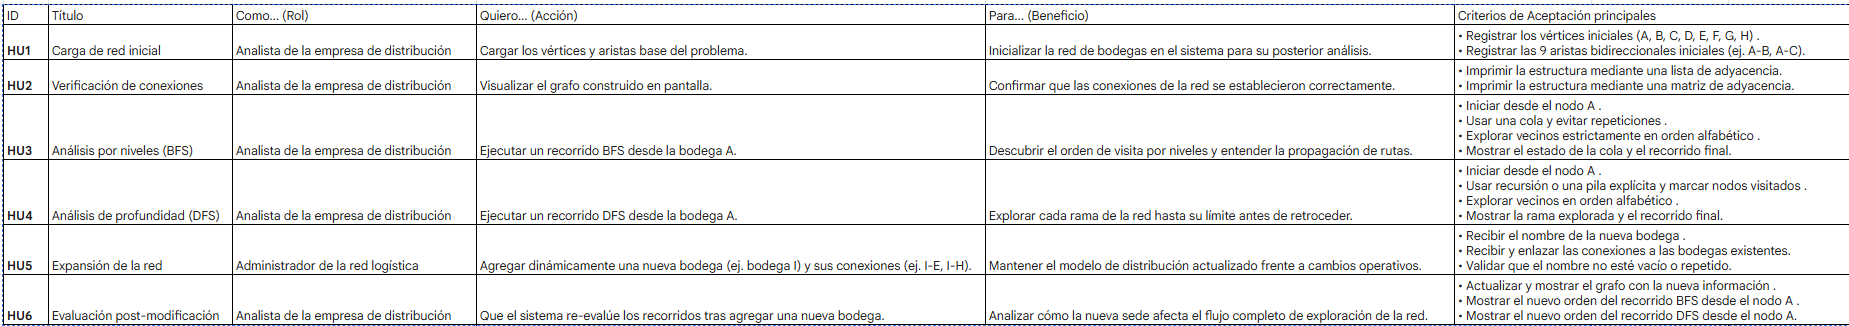







## 4) Diagramas de flujo **[5 pts]**

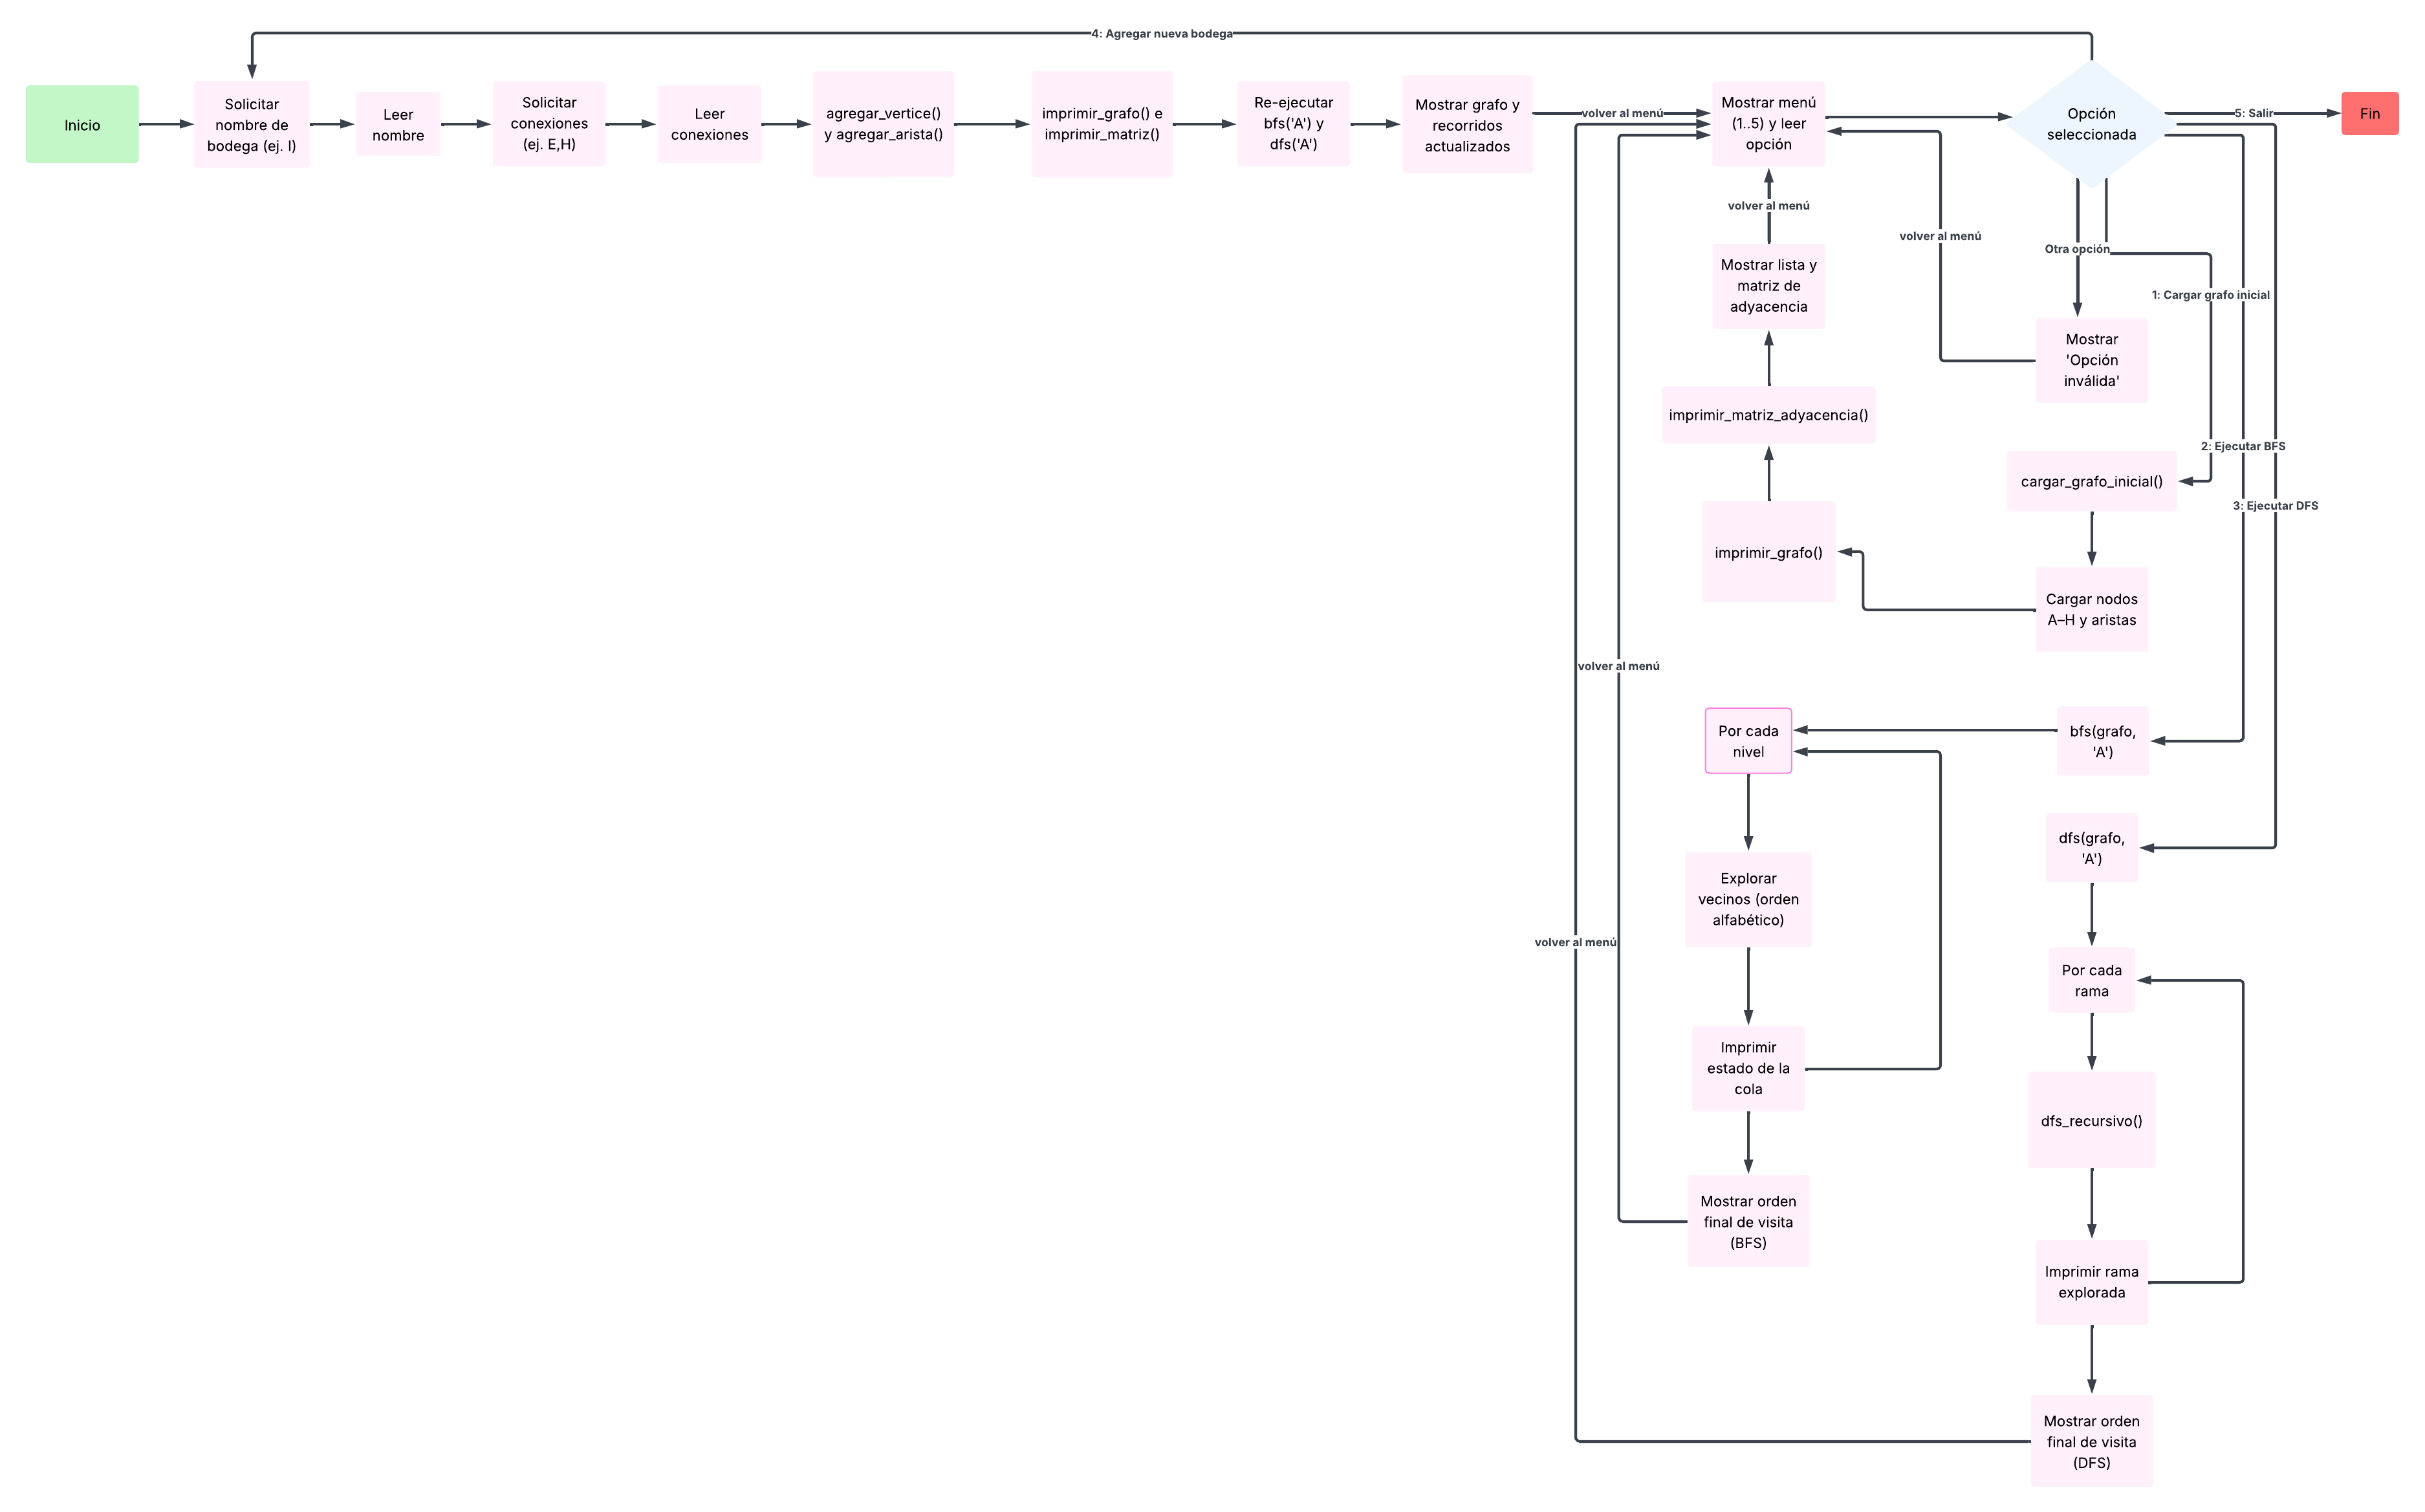





## 5) Diagramas de secuencia **[5 pts]**
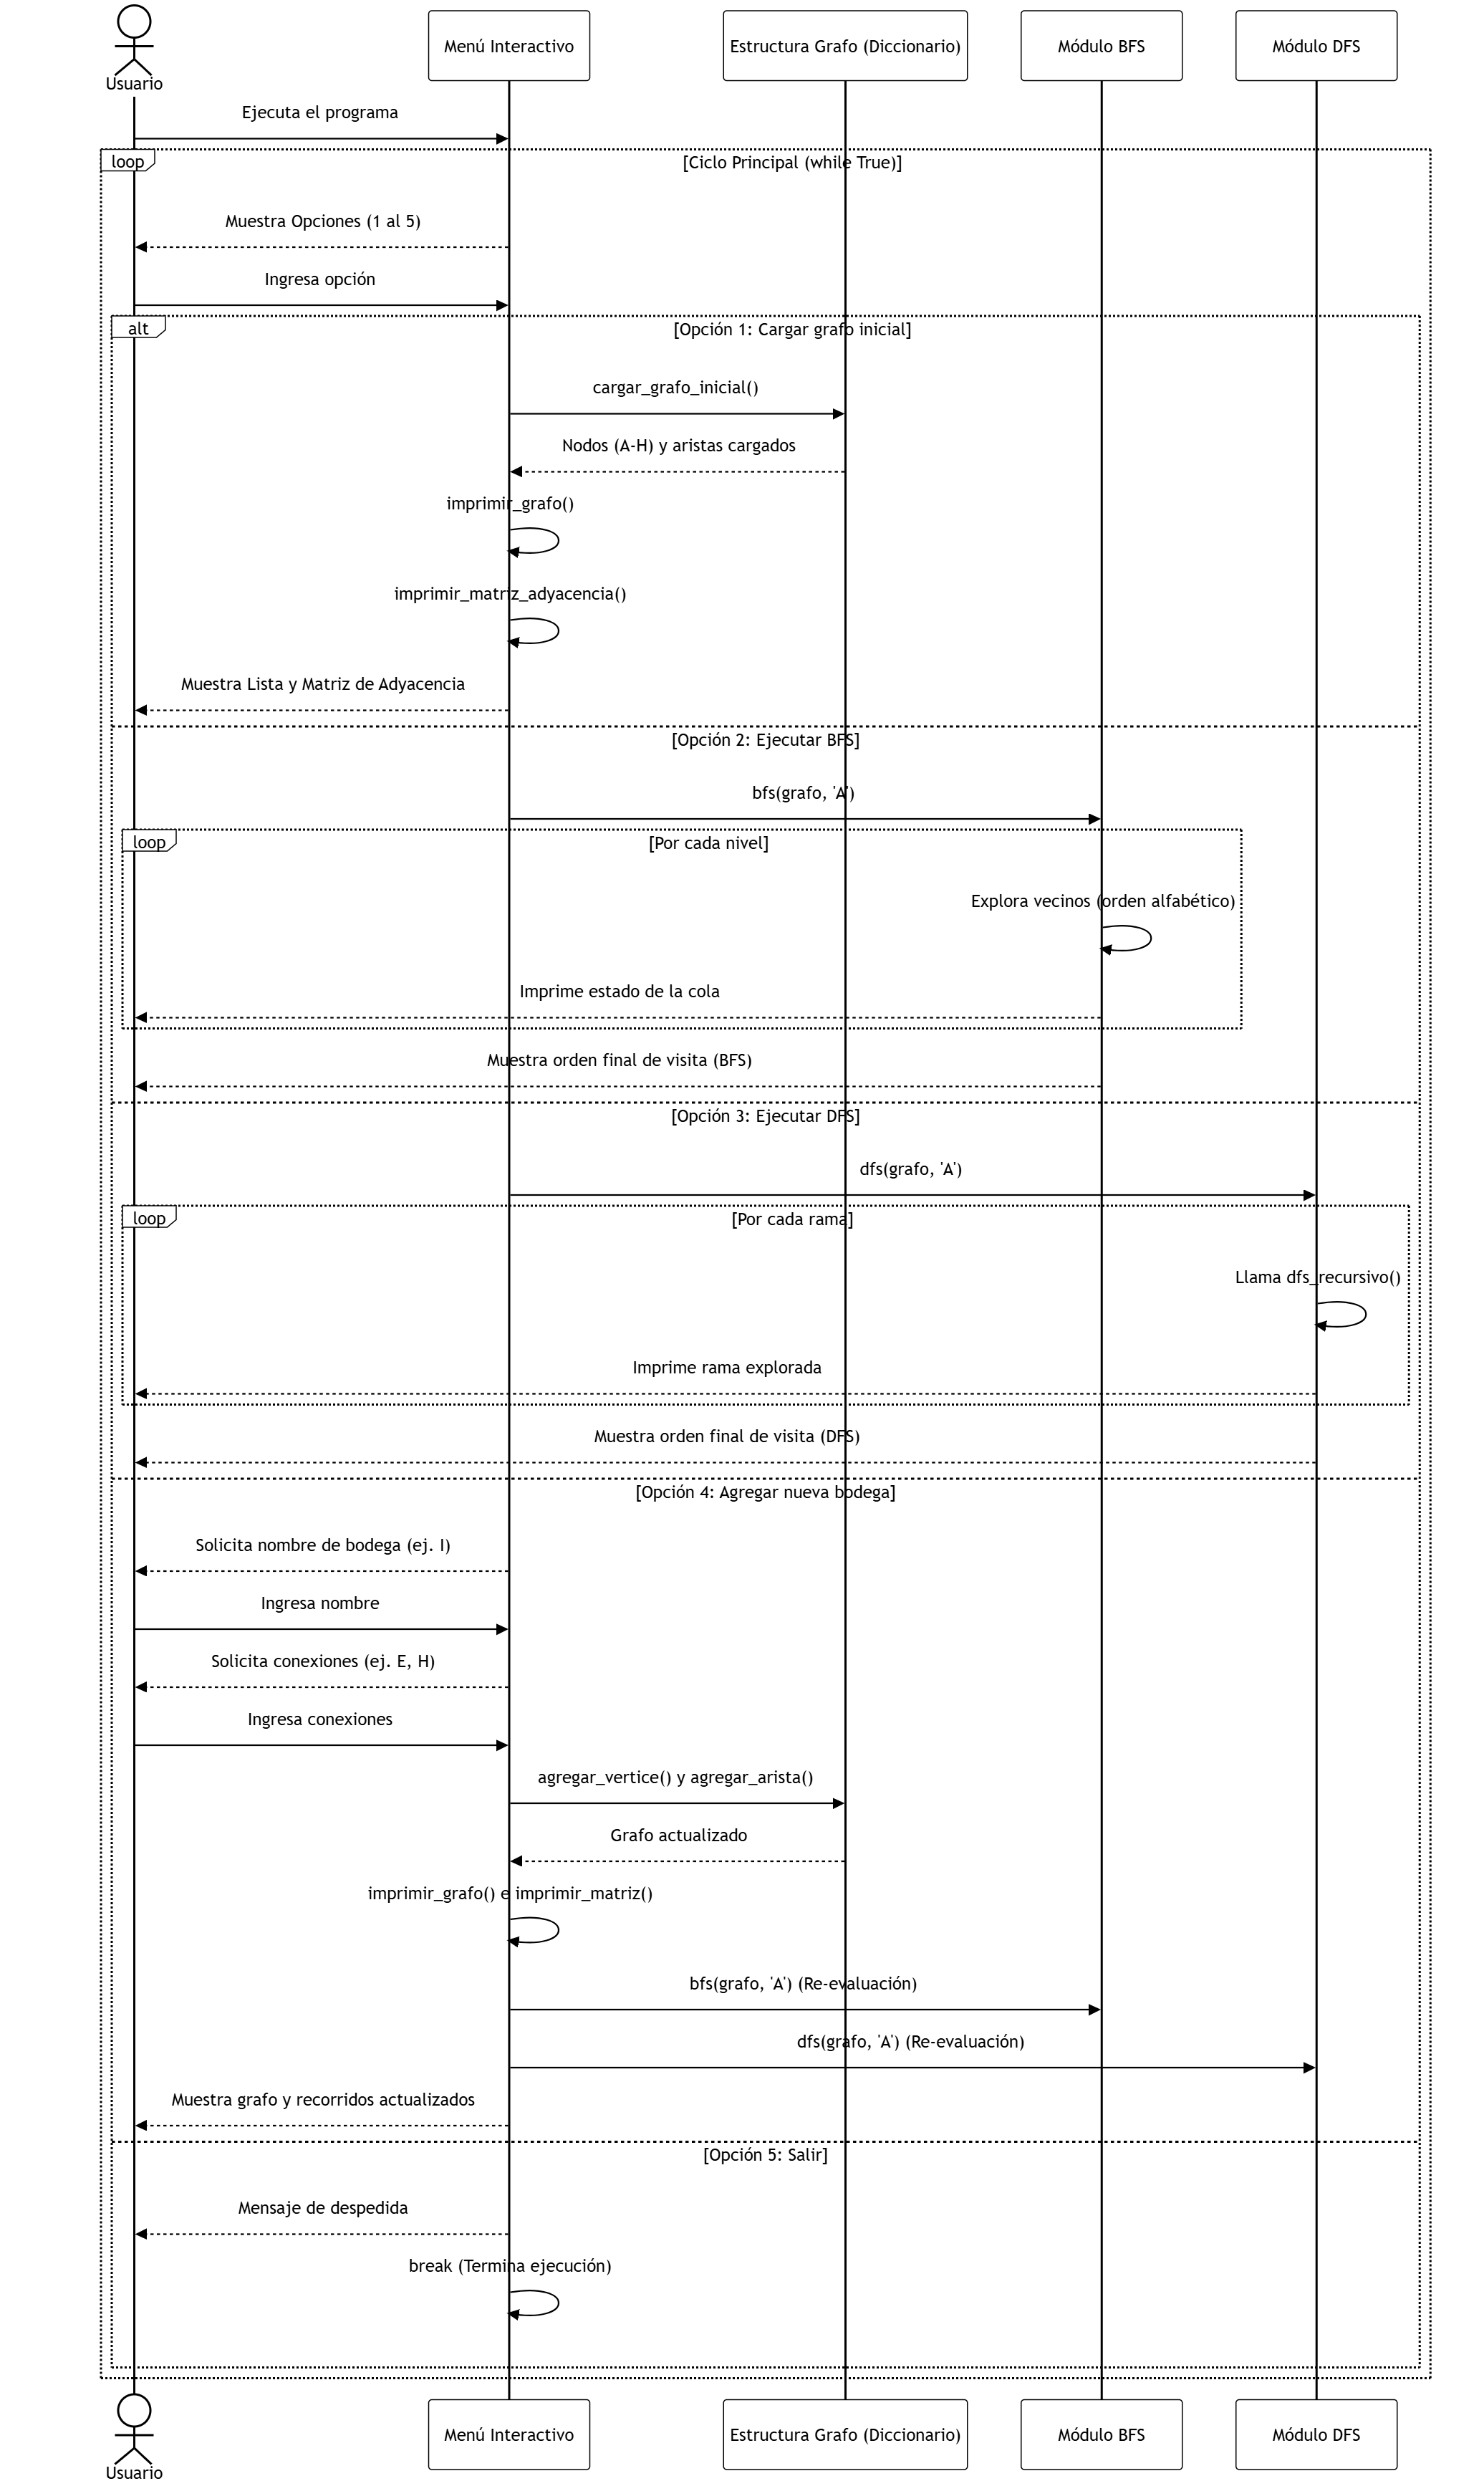

## 6) Diagramas de casos de uso **[5 pts]**


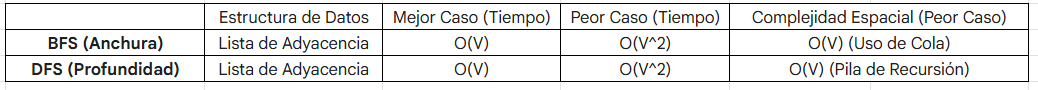
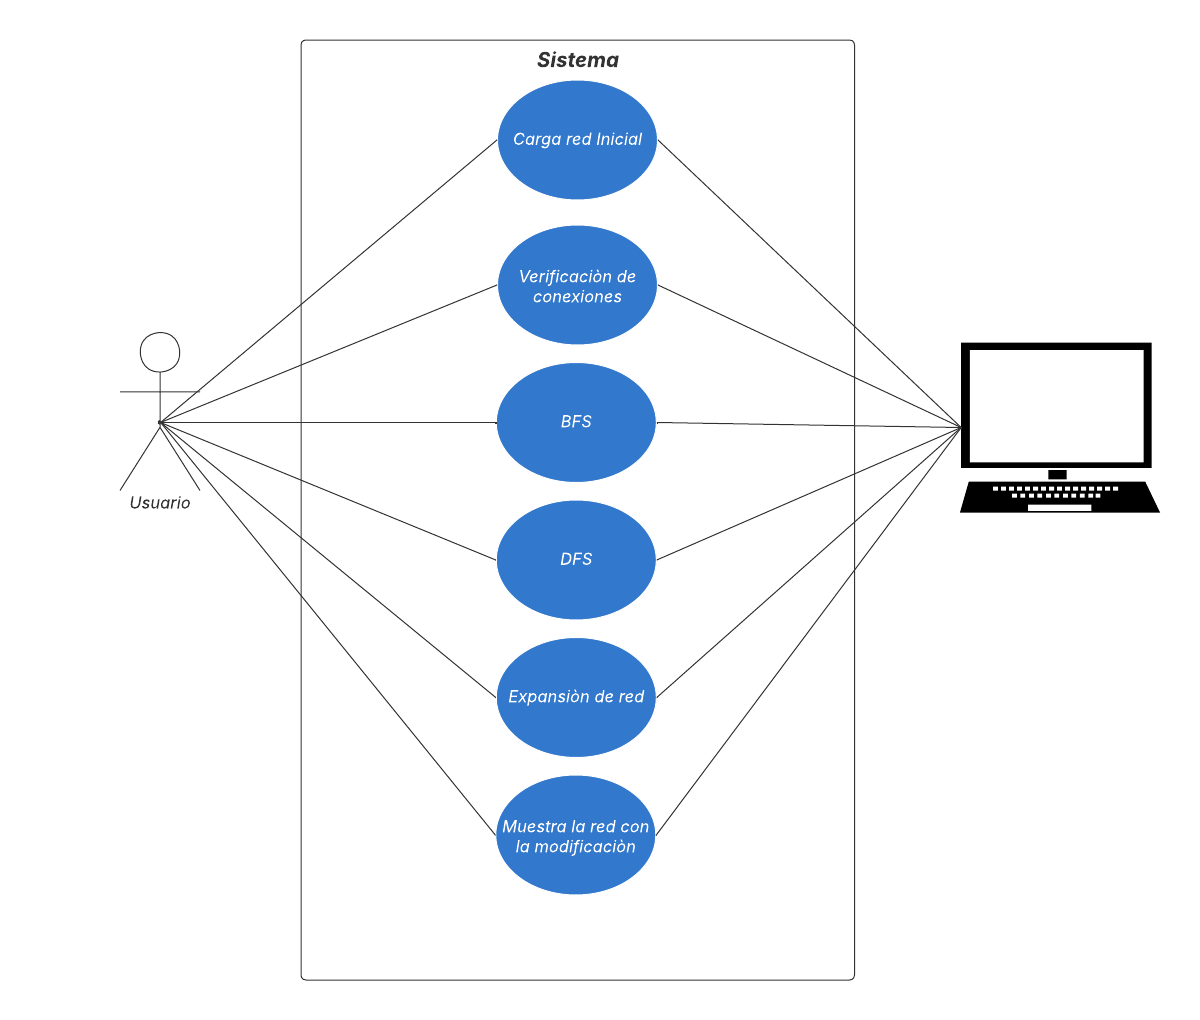

## 8) Tests **[5 pts]**
- Test 1 - Inserción

 Entrada:
 Inserción de múltiples elementos

 Salida esperada:
 Los elementos se organizan respetando la propiedad del BST

- Test 2 - Búsqueda existente

 Entrada:
Búsqueda de un elemento presente

 Salida esperada:
Elemento encontrado

- Test 3 - Búsqueda inexistente

 Entrada:
Búsqueda de un elemento no presente

 Salida esperada:
Elemento no encontrado



## 9) Código funcional **[15 pts]**



In [ ]:
# Escribe tu código aquí.
# Debe incluir: validación, función memoizada, y ejecución.
# Laboratorio: Estructuras de Datos Tipo Árbol

def solicitar_lista_numeros(mensaje):
    """Función auxiliar: Pide al usuario una lista de números y evita que el programa falle si ingresa letras."""
    while True:
        entrada = input(mensaje)
        try:
            # Separa el texto por comas, limpia espacios y lo convierte a números enteros
            partes = entrada.split(',')
            numeros = [int(p.strip()) for p in partes if p.strip()]
            if numeros:
                return numeros
            else:
                print("ERROR: Debes ingresar al menos un número.")
        except ValueError:
            # Si el usuario ingresa una letra, se captura el error sin detener el programa
            print("ERROR: Por favor, ingresa solo números separados por comas (ejemplo: 50, 30, 70).")

def insertar_arbol(arbol, elemento):
    # Validamos que sea un número por seguridad
    if not isinstance(elemento, (int, float)):
        print(f"Advertencia: El elemento '{elemento}' no es válido y será omitido.")
        return arbol

    # Restricción: Un árbol binario puede tener máximo dos hijos
    if arbol is None:
        return [elemento, None, None]

    # Restricción BST: Los menores a la izquierda y los mayores a la derecha
    if elemento < arbol[0]:
        arbol[1] = insertar_arbol(arbol[1], elemento)
    elif elemento > arbol[0]:
        arbol[2] = insertar_arbol(arbol[2], elemento)
    return arbol

def imprimir_arbol_visual(arbol, nivel=0):
    """Dibuja el árbol en consola girado"""
    if arbol is not None:
        imprimir_arbol_visual(arbol[2], nivel + 1)
        print('    ' * nivel + '-> ' + str(arbol[0]))
        imprimir_arbol_visual(arbol[1], nivel + 1)

def buscar_arbol(arbol, elemento):
    if arbol is None:
        return False
    if elemento == arbol[0]:
        return True
    if elemento < arbol[0]:
        return buscar_arbol(arbol[1], elemento)
    else:
        return buscar_arbol(arbol[2], elemento)

def inorden(arbol):
    if arbol is not None:
        inorden(arbol[1])
        print(arbol[0], end=" ")
        inorden(arbol[2])

def preorden(arbol):
    if arbol is not None:
        print(arbol[0], end=" ")
        preorden(arbol[1])
        preorden(arbol[2])

def postorden(arbol):
    if arbol is not None:
        postorden(arbol[1])
        postorden(arbol[2])
        print(arbol[0], end=" ")

# --- ACTIVIDADES ---

def actividad1(arbol_actual):
    print("\n--- Actividad 1: Construcción del árbol BST ---")
    print("Guía del laboratorio: Se sugieren los códigos 50, 30, 70, 20, 40, 60, 80.")

    elementos = solicitar_lista_numeros("Ingresa los códigos de los computadores separados por coma: ")

    # Insertar los números ingresados por el usuario
    for elemento in elementos:
        arbol_actual = insertar_arbol(arbol_actual, elemento)

    print("\nRepresentación visual del árbol:")
    imprimir_arbol_visual(arbol_actual)
    return arbol_actual  # Retornamos el árbol para guardarlo

def actividad2(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return

    print("\n--- Actividad 2: Búsqueda ---")
    print("Guía del laboratorio: Se sugiere buscar 60, 25 y 80[cite: 39, 40, 41].")

    elementos = solicitar_lista_numeros("Ingresa los códigos que deseas buscar, separados por coma: ")

    for elemento in elementos:
        encontrado = buscar_arbol(arbol_actual, elemento)
        resultado = "SÍ está en el inventario" if encontrado else "NO está en el inventario"
        print(f"Buscar {elemento}: {resultado}")

def actividad3(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return

    print("\n--- Actividad 3: Recorridos ---")
    print("Preorden (raíz, izquierda, derecha):")
    preorden(arbol_actual)

    print("\n\nInorden (izquierda, raíz, derecha):")
    inorden(arbol_actual)

    print("\n\nPostorden (izquierda, derecha, raíz):")
    postorden(arbol_actual)
    print("\n")

def actividad4(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return arbol_actual

    print("\n--- Actividad 4: Inserción de nuevos computadores ---")
    print("Guía del laboratorio: Se sugiere insertar 25, 65 y 90.")

    nuevos = solicitar_lista_numeros("Ingresa los nuevos códigos a insertar, separados por coma: ")

    for elemento in nuevos:
        arbol_actual = insertar_arbol(arbol_actual, elemento)
        print(f"\nÁrbol después de insertar el código {elemento}:")
        imprimir_arbol_visual(arbol_actual)
        print("-" * 30)

    return arbol_actual

def actividad5():
    arbol_temporal = None
    print("\n--- Actividad 5: Análisis de desbalanceo ---")
    print("Guía del laboratorio: Se sugiere insertar 10, 20, 30, 40 y 50 en un árbol vacío.")

    elementos = solicitar_lista_numeros("Ingresa una secuencia de números separados por coma: ")

    for elemento in elementos:
        arbol_temporal = insertar_arbol(arbol_temporal, elemento)

    print("\nForma del árbol resultante:")
    imprimir_arbol_visual(arbol_temporal)

    print("\nAnálisis: Si ingresaste números ya ordenados de menor a mayor en un BST vacío,")
    print("todos los elementos son mayores que la raíz y se insertan a la derecha.")
    print("El árbol queda desbalanceado hacia la derecha, perdiendo eficiencia.")

def actividad6():
    print("\n--- Actividad 6: Uso de AVL ---")
    print("Guía del laboratorio: Se sugiere insertar 10, 20 y 30 en un árbol AVL.")

    elementos = solicitar_lista_numeros("Ingresa 3 números ordenados ascendentemente, separados por coma: ")

    if len(elementos) >= 3:
        print(f"\n1. Se inserta {elementos[0]} (Raíz).")
        print(f"2. Se inserta {elementos[1]} (Hijo derecho de {elementos[0]}).")
        print(f"3. Se inserta {elementos[2]} (Hijo derecho de {elementos[1]}).")
        print("Análisis: El árbol se desbalancea hacia la derecha.")
        print(f"Solución: Se realiza una rotación simple a la izquierda sobre el nodo {elementos[0]}.")
        print(f"Resultado: {elementos[1]} se convierte en la nueva raíz balanceando las alturas.")
    else:
        print("Debías ingresar al menos 3 números para simular la rotación.")

def menu():
    print("\n---- Menú: Inventario de Computadores ----")
    print("1. Actividad 1: Construcción del árbol BST")
    print("2. Actividad 2: Búsqueda")
    print("3. Actividad 3: Recorridos")
    print("4. Actividad 4: Inserción de nuevos computadores")
    print("5. Actividad 5: Análisis de desbalanceo")
    print("6. Actividad 6: Uso de AVL")
    print("0. Salir")

def main():
    opcion = ""
    # Creamos la variable principal que almacenará el árbol para que las actividades compartan los datos
    arbol_principal = None

    while opcion != "0":
        menu()
        opcion = input("\nIngrese una opción: ").strip()

        if opcion == "1":
            arbol_principal = actividad1(arbol_principal)
        elif opcion == "2":
            actividad2(arbol_principal)
        elif opcion == "3":
            actividad3(arbol_principal)
        elif opcion == "4":
            arbol_principal = actividad4(arbol_principal)
        elif opcion == "5":
            actividad5()
        elif opcion == "6":
            actividad6()
        elif opcion == "0":
            print("\nPrograma finalizado.")
        else:
            print("\n" + "="*50)
            print("ERROR: Entrada no válida.")
            print(f"Ingresaste: '{opcion}'. Por favor, escribe solo un número del 0 al 6.")
            print("="*50)

if __name__ == "__main__":
    main()

### Test aplicados

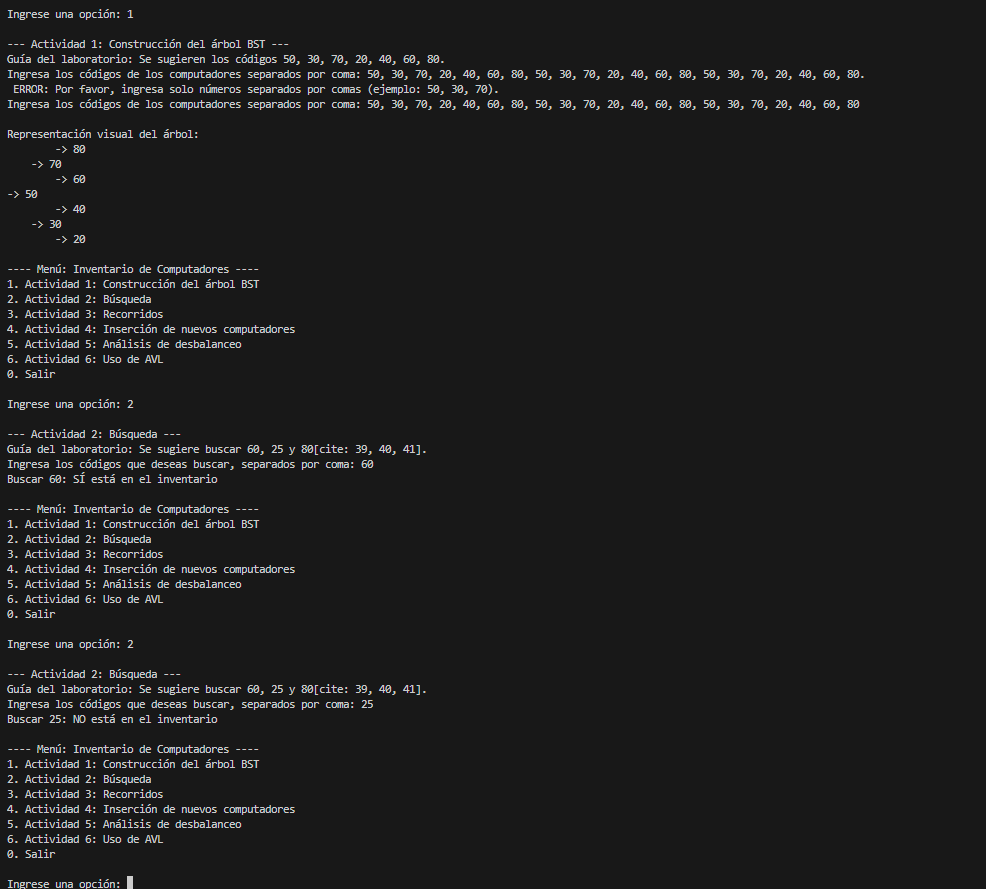